# Uue reegli testimine

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path
import os
import sys
import pickle

import pandas as pd

from estnltk.storage.postgres import PostgresStorage

from rule_based_ner_correction import run_rule_analysis_on_items, compare_change_rows
from rule_based_ner_correction.boundary.base import BaseRule, RuleProposal
from rule_based_ner_correction.missing.base import BaseMissingRule, MissingProposal
from rule_based_ner_correction.visualizer import draw_tree

In [ ]:
OUTPUT_DIR = Path('outputs/single_rule_tests')
MAX_TEXTS = 10000

BASE_LAYER = 'v171_named_entities'
OUTPUT_LAYER = 'single_rule_test'
MORPH_LAYER = 'morph_analysis'
SYNTAX_LAYER = 'v172_stanza_syntax'

LAYERS=['words', MORPH_LAYER, SYNTAX_LAYER, BASE_LAYER]

## Andmete sisselugemine koondkorpuse andmebaasist

In [ ]:
def load_items(collection, max_texts=MAX_TEXTS):
    items = []
    for text_id, text in collection.select(layers=LAYERS):
        items.append((text_id, text))
        if max_texts is not None and len(items) >= max_texts:
            break
    return items

In [6]:
pgpass_file = 'pgpass.txt'
assert os.path.exists(pgpass_file)

storage = PostgresStorage(
    pgpass_file=pgpass_file,
    schema='estonian_text_corpora',
    role='estonian_text_corpora_read'
)

collection_name = 'koondkorpus_sentences_test_5000_sg_thread'
collection = storage[collection_name]

items = load_items(collection)
print(len(items))

storage.close()

INFO:storage.py:57: connecting to host: 'postgres.keeleressursid.ee', port: '5432', dbname: 'estonian-text-corpora', user: 'kaarelku'
INFO:storage.py:108: schema: 'estonian_text_corpora', temporary: False, role: 'estonian_text_corpora_read'
100000


## Reegli toorik

Boundary-reegel on `BaseRule` alamklass.

Missing-reegel on `BaseMissingRule` alamklass.

In [ ]:
class MyTestRule(BaseRule):
    rule_id = 'minu_testireegel'
    description = 'Notebookis kirjutatud katsetusreegel.'

    def applies_to(self, span, context):
        return span.label == 'ORG'

    def propose(self, span, context):
        next_token = context.next_token(span)
        if next_token is None:
            return None
        if next_token.text.upper() not in {'AS', 'OÜ', 'OU'}:
            return None

        new_span = context.span_from_indices(span.label, span.start_i, span.end_i + 1)
        return RuleProposal(
            rule_id=self.rule_id,
            operation='replace',
            score=0.99,
            spans=[new_span],
        )


rule = MyTestRule()

## Testimine

In [24]:
result = run_rule_analysis_on_items(
    items=items,
    rule=rule,
    output_dir=OUTPUT_DIR,
    base_layer=BASE_LAYER,
    output_layer=OUTPUT_LAYER,
    morph_layer=MORPH_LAYER,
    syntax_layer=SYNTAX_LAYER,
)

change_rows = result['change_rows']
proposal_rows = result['proposal_rows']
corrected_items = result['corrected_items']

result['paths']['change_rows']

100%|██████████| 100000/100000 [04:22<00:00, 380.86it/s]


WindowsPath('outputs/single_rule_tests/lahuta_mittesidus_ne_puu_change_rows.csv')

### Tulemus

In [25]:
result['summary']

,kind,name,count
0,change_type,SPLIT,748
1,label,LOC,31748
2,label,PER,31518
3,label,ORG,19809
4,top_text,"Nigel Short ( GBR ) - Andrei Sokolov ( RUS ) 2 : 0 ; Kiril Georgiev ( BUL ) - Vadim Milov ( SUI ) 1,5 : 0,5 ; Aleksei Drejev ( RUS ) - Matthew Sadler ( GBR ) 1,5 : 0,5 ; Zoltan Almasi ( HUN ) - Artur Jussupov ( GER ) 1,5 : 0,5 ; Zurab Azmaiparashvili ( GEO ) - Aleksei Aleksandrov ( BLR ) 1,5 : 0,5 ; Mihhail Krassenkov ( POL ) - Jevgeni Barejev ( RUS ) 1,5 : 0,5 ; Michael Adams ( GBR ) - Sergei Tivjakov ( RUS ) 1,5 : 0,5 ; Pjotr Svidler ( RUS ) - Vladimir Jepishin ( RUS ) 1,5 : 0,5 ; Jeroen Piket ( HOL ) - Loek van Wely ( HOL ) 1 : 1 ; Aleksandr Halifman ( RUS ) - Viswanathan Anand ( IND ) 1 : 1 ; Gilberto Milos ( BRA ) - Aleksei Shirov ( SPA ) 1 : 1 ; Aleksandr Beljavski ( SLO ) - Sergei Rublevski ( RUS ) 1 : 1 ; Joel Lautier ( FRA ) - Boriss Gelfand ( BLR ) 1 : 1 ; Lembit Oll ( EST ) - Vladislav Tkatshov ( KZK ) 1 : 1 ; Vladimir Zvjagintsev ( RUS ) - Yasser Seirawan ( USA ) 1 : 1 ; Rafael Vaganjan ( ARM ) - Vladimir Akopjan ( ARM ) 1 : 1.",63
5,top_text,"Detroit - Orlando 81 : 88 ( Hunter 25 , Hill 18 , Reid 15 - Hardaway 27 , Armstrong 17 , Harpring 13 ) , Phoenix - Seattle 99 : 93 ( Gugliotta 27 , 12lp , Robinson 23 , Kidd 15 , 11rs , Manning 14 - Payton 21 , 11rs , Schrempf 20 , 10lp , MacLean 16 ) , Vancouver - Golden State 85 : 90 ( Rahim 25 , Lopez 17 - Marshall 24 , Starks 14 ) , Miami - Indiana 92 : 88 ( Mourning 24 , 16lp , Brown 16 - A . Davis 18 , 12lp , Miller 17 , Rose 16 ) , San Antonio - Houston 86 : 83 ( Elie 21 , Elliott 16 , Robinson 14 , 14lp , - Barkley 23 , 15lp , 8rs , Olajuwon 18 , 11lp ) , Chicago - Milwaukee 79 : 77 ( Kukoc 22 , Brown 16 , 7lp , 10rs - Allen 19 , Robinson 17 ) , LA Clippers - Denver 101 : 103 ( Taylor 28 , Douglas , Murray 14 - Van Exel 34 , Fortson 20 , 14lp , McDyess 18 , 10lp ) , New Jersey - Philadelphia 86 : 79 ( Van Horn 26 , 12lp , Burrell , Gill 15 - Hill 23 , 13lp , McKie 15 ) , Washington - Boston 98 : 101 ( Strickland 31 , 12rs , Richmond 17 - Pierce 26 , McCarty 16 , Potapenko 15 ) .",55
6,top_text,"Peatreener Aleksander Romantsovi valikul esindavad Eestit väravavahid Andrus Ahi ( Tartu Välk-494 ) ja Aleksei Terentjev ( Peterburi Izhorets ) , kaitsjad Vjatsheslav Kulpin , Roman Potshinok ( mõlemad Tartu Välk-494 ) , Gennadi Rõzhkov ( Narva Kreenholm ) , Nikolai Kuhharuk ( Alajoenkoski AaKoo ) , Stanislav Pankov ( Tallinna Hokitsenter ) , Aleksandr Agnevtshikov ( Pensa Dizelist ) ja Lauri Lahesalu ( Tampere Tappara jun. ) ning ründajad Olle Sildre ( Uusikaupunki Jää-Kotkat ) , Oleg Puzanov , Mihhail Kozlov ( mõlemad Tartu Välk-494 ) , Aleksei Filippov ( Tallinna Hokitsenter ) , Georgi Kozlov ( IHK Lillehammer ) , Igor Ossipenkov ( Narva Kreenholm ) , Ivan Loginov ( Peterburi SKA ) , Valeri Lebedev ( Tartu Välk-494 ) Eduard Valiullin ( Tjumeni Rubin ) , Andrei Makrov ( Helsingi IFK jun. ) , Andrei Zorin ( Alajoenkoski AaKoo ) , Maksim Ivanov ( Nizhni Novgorodi Torpedo ) ja Pelle Sildre ( Tallinna Hokitsenter ) .",43
7,top_text,"Ajakirjanike meeskonnas jooksevad platsile : Ivar Jurtšenko ( ETV ) , Priit Kuusk ( ETV ) , Kalle Muuli ( Postimees ) , Alex Lepajõe ( TV3 ) , Hanno Tomberg ( TV3 ) , Timo Tarve ( Kuku raadio ) , Peep Pahv ( SL Õhtuleht ) , Tarmo Paju ( SL Õhtuleht ) , Indrek Schwede ( vabakutseline ) , Raivo Rauts ( SL Õhtuleht ) , Andres Vaher ( SL Õhtuleht ) , Andres Kalvik ( SL Õhtuleht ) , Jaan Martinson ( SL Õhtuleht ) , Ants Põldoja ( SL Õhtuleht ) , Janar Filippov ( Eesti Ekspress ) , Roald Johansson ( ETA ) , Jan Jõgis-Laats ( BNS ) , Raimo Nõu ( Kalevlane ) , Veiko Kampura ( Soccernet ) , Aivo Vahemets ( EPL ) .",37
8,top_text,"Esinesid Renate Pajusalu ( TÜ ) "" Jumal ja kurat argikeeles "" , Mart Raukas ( TLÜ ) "" Jumala silm ja jumala kulm "" , Enn Kasak ( TLÜ ) "" Kuradi tark jumala loll "" , Anne Kull ( TÜ ) "" Ühesugused sõnad - erinevad tähendused "" , Meelis Friedenthal ( TÜ ) "" Täiuslikust nägemisest "" , Peeter Lorents ( Estonian Business Scho

In [ ]:
change_rows[:20]

,text_id,change_type,base_count,new_count,base_texts,new_texts,base_labels,new_labels,base_lemmas,new_lemmas,...,new_internal_root_morph_pos,base_external_head_texts,new_external_head_texts,base_external_head_deprels,new_external_head_deprels,base_external_head_morph_pos,new_external_head_morph_pos,text,source_stage,source_rule
0,2,SPLIT,1,2,"[[Mathers, III]]","[Mathers, III]",[PER],"[PER, PER]","[[Mathers, III]]","[[Mathers], [III]]",...,"[[H], [O]]","[[Eminem, Marshall]]","[[Eminem], [Marshall]]","[[nsubj, flat]]","[[nsubj], [flat]]","[[H, H]]","[[H], [H]]",Kolme aastaga on Eminem alias Marshall Mathers III ( 30 ) kindlalt meie teadvusesse sööbinud .,boundary,lahuta_mittesidus_ne_puu
1,333,SPLIT,1,2,"[[Maretile, Aurumi]]","[Maretile, Aurumi]",[PER],"[PER, PER]","[[Maret, Aurum]]","[[Maret], [Aurum]]",...,"[[H], [H]]","[[kinkis, kullaäri]]","[[kinkis], [kullaäri]]","[[root, nmod]]","[[root], [nmod]]","[[V, S]]","[[V], [S]]",Sõrmuse kinkis Maretile Aurumi kullaäri omanik Heli Kuulman ja traditsiooni järgi peabki see ema kaelas rippuma .,boundary,lahuta_mittesidus_ne_puu
2,360,SPLIT,1,2,"[[Krasnodarka, külades]]","[Krasnodarka, külades]",[LOC],"[LOC, LOC]","[[Krasnodarka, küla]]","[[Krasnodarka], [küla]]",...,"[[H], [S]]","[[Petrovka, peeti]]","[[Petrovka], [peeti]]","[[nmod, root]]","[[nmod], [root]]","[[H, V]]","[[H], [V]]",Suvel peeti Petrovka ja Krasnodarka külades Eesti Suvepäevad Krimmis .,boundary,lahuta_mittesidus_ne_puu
3,487,SPLIT,1,2,"[[Bureau, Veritas, Estline'i]]","[Bureau Veritas, Estline'i]",[ORG],"[ORG, ORG]","[[Bureau, Veritas, Estline]]","[[Bureau, Veritas], [Estline]]",...,"[[H], [H]]","[[vaatas, omanduseks]]","[[vaatas], [omanduseks]]","[[root, xcomp]]","[[root], [xcomp]]","[[V, S]]","[[V], [S]]",1990. aasta suvel vaatas Bureau Veritas Estline'i omanduseks saanud laeva uuesti üle ja kirjutas klassitunnistusse taas Deep Sea .,boundary,lahuta_mittesidus_ne_puu
4,549,SPLIT,1,2,"[[Heltermaa-Rohuküla, ja, Sviby-Rohuküla]]","[Heltermaa-Rohuküla, Sviby-Rohuküla]",[LOC],"[LOC, LOC]","[[Heltermaa-Rohuküla, ja, Sviby-Rohuküla]]","[[Heltermaa-Rohuküla], [Sviby-Rohuküla]]",...,"[[H], [H]]",[[Kuivastu-Virtsu]],"[[Kuivastu-Virtsu], [Kuivastu-Virtsu]]",[[nmod]],"[[nmod], [nmod]]",[[H]],"[[H], [H]]","Lepinguga tagati laevakompaniile ainuõigus teha kümne aasta jooksul Kuivastu-Virtsu , Heltermaa-Rohuküla ja Sviby-Rohuküla liinidel riigi poolt doteeritavaid reise .",boundary,lahuta_mittesidus_ne_puu
5,709,SPLIT,1,2,"[[Ameerika, linnades]]","[Ameerika, linnades]",[LOC],"[LOC, LOC]","[[Ameerika, linn]]","[[Ameerika], [linn]]",...,"[[H], [S]]","[[Venemaa, etendati]]","[[Venemaa], [etendati]]","[[nmod, root]]","[[nmod], [root]]","[[H, V]]","[[H], [V]]","Lurichi meheteod etendati kodust kaugel , Venemaa , Euroopa ja Ameerika linnades , ning surigi ta eemal , salapäraselt ja kurvalt .",boundary,lahuta_mittesidus_ne_puu
6,851,SPLIT,1,2,"[[Linnateater, ja, Ugala]]","[Linnateater, Ugala]",[ORG],"[ORG, ORG]","[[Linnateater, ja, Ugala]]","[[Linnateater], [Ugala]]",...,"[[H], [H]]",[[Endla]],"[[Endla], [Endla]]",[[nsubj]],"[[nsubj], [nsubj]]",[[H]],"[[H], [H]]","Vanemuise draamapoolele oli planeeritud 42 etendust , järgnevad Endla ( 34 ) , Vene Draamateater ( 25 ) , Linnateater ja Ugala ( 23 ) , Nukuteater ( 22 ) , Vanalinnastuudio ( 21 ) .",boundary,lahuta_mittesidus_ne_puu
7,1377,SPLIT,1,2,"[[McDonald, ', siga]]","[McDonald', siga]",[PER],"[PER, PER]","[[McDonald, ’, siga]]","[[McDonald, ’], [siga]]",...,"[[H], [S]]","[[midagi, analoogset]]","[[midagi], [analoogset]]","[[conj, amod]]","[[conj], [amod]]","[[P, A]]","[[P], [A]]","Vene rahvusroogade söögikohtade kett , midagi McDonald'siga analoogset , kuid palju rikkalikuma toiduvalikuga .",boundary,lahuta_mittesidus_ne_puu
8,1473,SPLIT,1,2,"[[Andrei, Rjabov, Carnegie]]","[Andrei Rjabov, Carnegie]",[PER],"[PER, PER]","[[Andrei, Rjabov, Carnegie]]","[[Andrei, Rjabov], [Carnegie]]",...,"[[H], [H]]","[[Nikolai, keskusest]]","[[Nikolai], [keskusest]]","[[obj, obl]]","[[obj], [obl]]","[[H, S]

### Kahe change_rows faili võrdlus


In [ ]:
OLD_CHANGE_ROWS = OUTPUT_DIR / 'lahuta_mittesidus_ne_puu_change_rows_0.csv'
NEW_CHANGE_ROWS = OUTPUT_DIR / 'lahuta_mittesidus_ne_puu_change_rows_1.csv'

comparison = compare_change_rows(OLD_CHANGE_ROWS, NEW_CHANGE_ROWS)
comparison['summary']


,category,count
0,added,0
1,removed,12
2,changed,4


In [ ]:
comparison['added'].head(30)


In [ ]:
comparison['removed'].head(30)


In [ ]:
comparison['changed'].head(30)


### Süntaksi puud

Text (10691): VILLE ARIKE


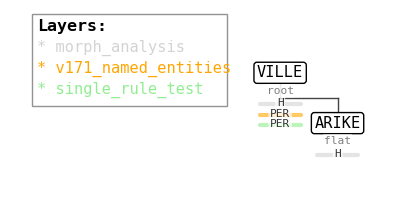

Text (18296): 22.10.2002 kella 10.30 ajal juhtus Pärnus Karja ja Hõbeda tänava ristmikul liiklusõnnetus , kus sõiduauto Opel Omega , mida juhtis Martti ( s. 1968 ) sõitis otsa ülekäigurajal tänavat ületanud Rudolfile ( s. 1926 ) .


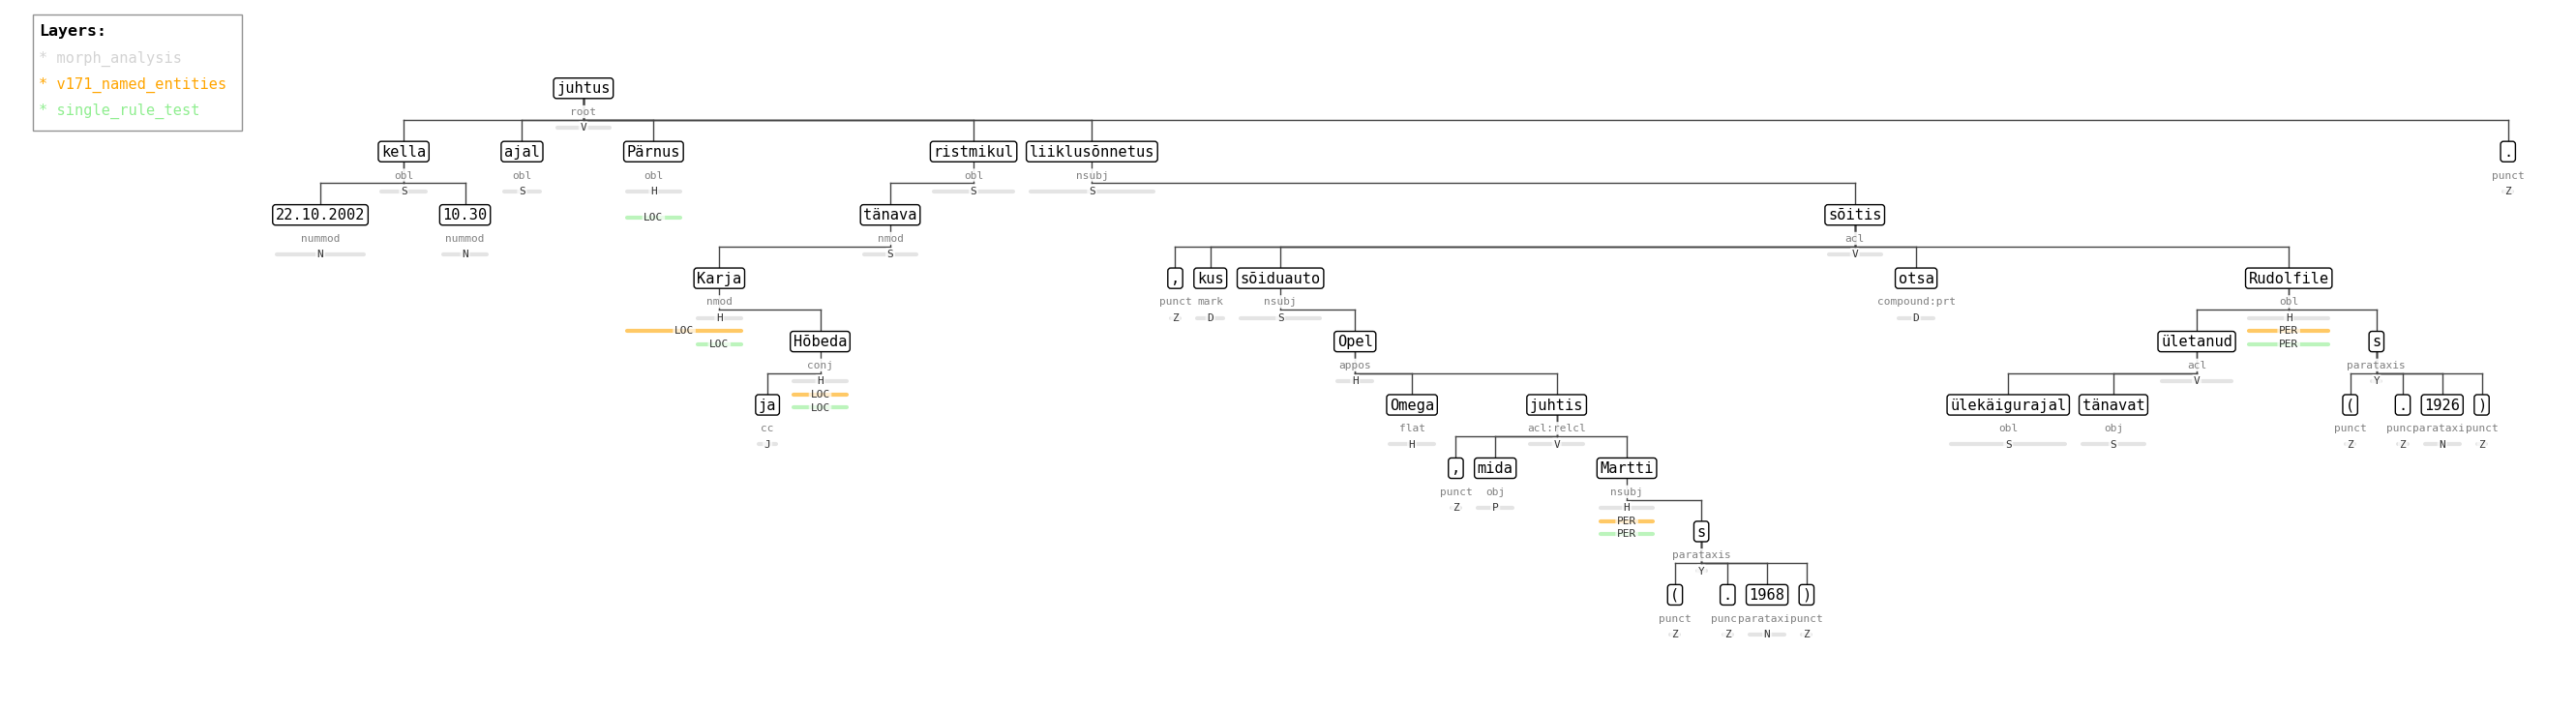

Text (44207): Johannes Paulus II puudutas isegi kommunistide hinge .


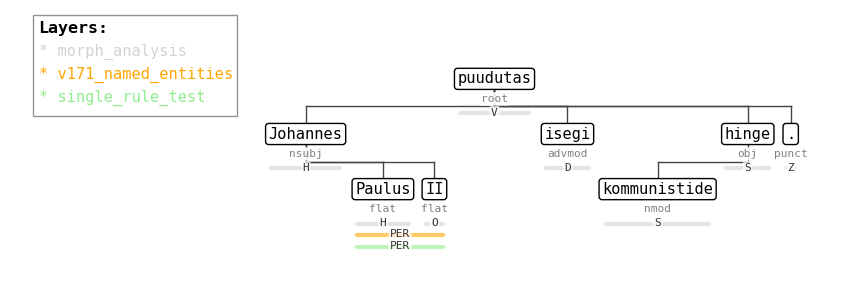

Text (47133): Abel Garcia Mendez ja Gustavo Sandoval tunnistasid end süüdi illegaalsete immigrantide transpordi pakkumises ja abistamises , Abel Ramirez Vasquez tunnistas end süüdi illegaalide transportimises , ütles riiklik süüdistaja Phillip Tripi .


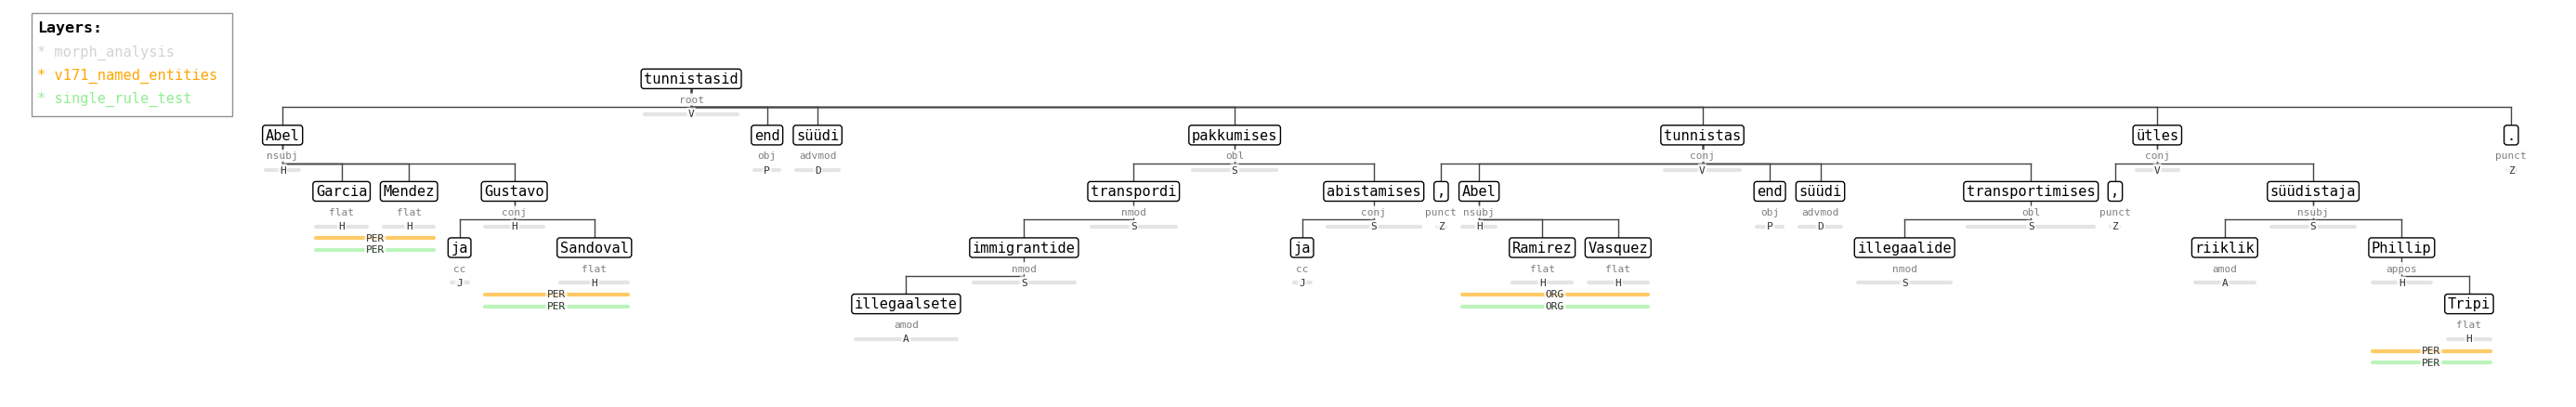

In [ ]:
text_ids = [60, 328, 333, 360, 487, 547, 549, 2423, 3973, 4288, 4428]

for id, text in corrected_items:
    if id in text_ids:
        print(f'Text ({id}): {text.text}')
        draw_tree(
            text, 
            syntax_layer=SYNTAX_LAYER, 
            spans=[
                {'name': MORPH_LAYER, 'color': 'lightgrey', 'label': 'partofspeech'},
                {'name': BASE_LAYER, 'color': 'orange', 'label': 'nertag'},
                {'name': OUTPUT_LAYER, 'color': 'lightgreen', 'label': 'nertag'},
            ]
)



## Taggeri katsetused

In [ ]:
from rule_based_ner_correction import RuleBasedNerCorrectionTagger
from rule_based_ner_correction import build_boundary_rule_list, build_missing_rule_list

from estnltk import Text
from estnltk.taggers import NerTagger
from estnltk_neural.taggers import StanzaSyntaxTagger

syntax_t = StanzaSyntaxTagger(output_layer='stanza_syntax')
ner_t = NerTagger()

tagger = RuleBasedNerCorrectionTagger(
    ner_layer="ner",
    morph_layer="morph_analysis",
    syntax_layer="stanza_syntax",
    output_layer="ner_corrected",
    boundary_rules=build_boundary_rule_list(),
    missing_rules=build_missing_rule_list(),
)

NameError: name 'get_default_boundary_rules' is not defined

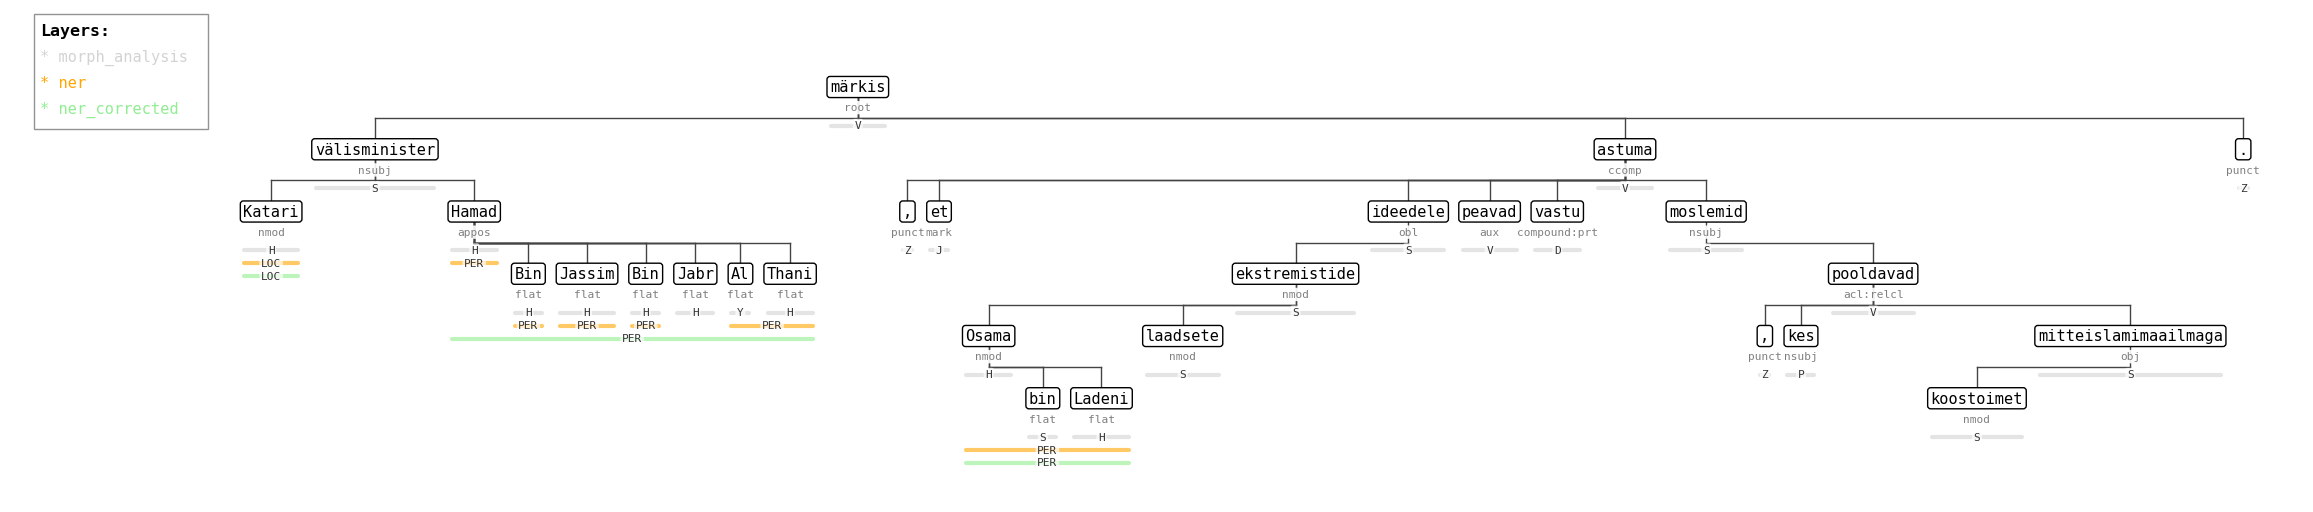

In [ ]:
test = Text('Katari välisminister Hamad Bin Jassim Bin Jabr Al Thani märkis, et Osama bin Ladeni laadsete ekstremistide ideedele peavad vastu astuma moslemid, kes pooldavad koostoimet mitteislamimaailmaga.')

test.tag_layer('morph_analysis')
syntax_t.tag(test)
ner_t.tag(test)
tagger.tag(test)

In [93]:
test.ner_corrected

Layer(name='ner_corrected', attributes=('nertag',), spans=SL[Span('Katari', [{'nertag': 'LOC'}]),
Span('Hamad Bin Jassim Bin Jabr', [{'nertag': 'PER'}]),
Span('Al Thani', [{'nertag': 'PER'}]),
Span('Osama bin Ladeni', [{'nertag': 'PER'}])])

In [ ]:
draw_tree(
    test, 
    syntax_layer="stanza_syntax", 
    spans=[
        {'name': "morph_analysis", 'color': 'lightgrey', 'label': 'partofspeech'},
        {'name': "ner", 'color': 'orange', 'label': 'nertag'},
        {'name': "ner_corrected", 'color': 'lightgreen', 'label': 'nertag'},
    ]
)